<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Load-Modules" data-toc-modified-id="Load-Modules-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Load Modules</a></span></li><li><span><a href="#Reused-functions" data-toc-modified-id="Reused-functions-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Reused functions</a></span></li><li><span><a href="#Make-an-example" data-toc-modified-id="Make-an-example-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Make an example</a></span></li><li><span><a href="#Compute-modularity" data-toc-modified-id="Compute-modularity-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Compute modularity</a></span><ul class="toc-item"><li><span><a href="#Example-1" data-toc-modified-id="Example-1-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Example 1</a></span></li><li><span><a href="#Example-2:-0-&amp;-1-in-community" data-toc-modified-id="Example-2:-0-&amp;-1-in-community-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Example 2: 0 &amp; 1 in community</a></span></li><li><span><a href="#Example-2:-0-&amp;-2-in-community" data-toc-modified-id="Example-2:-0-&amp;-2-in-community-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Example 2: 0 &amp; 2 in community</a></span></li><li><span><a href="#Example-1-and-2-in-same-community?" data-toc-modified-id="Example-1-and-2-in-same-community?-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Example 1 and 2 in same community?</a></span></li></ul></li><li><span><a href="#Average-degree-matrix" data-toc-modified-id="Average-degree-matrix-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Average degree matrix</a></span></li></ul></div>

# Modularity calculations

## Load Modules

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
opts = { "with_labels": True, "node_color": 'y' } 

## Reused functions

In [57]:
def Draw_G_with_edge_weights(G):
    pos = nx.circular_layout(G)
    weights = nx.get_edge_attributes(G, "weight")
    wedge_widths = [weights[(u, v)] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=800, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_widths)
    nx.draw_networkx_labels(G, pos, font_size=11, font_color="white")

    edge_labels = {e: f"{w:.2f}" for e, w in weights.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

## Make an example

In [45]:
edges = [
    (0, 1, 1.0),
    (0, 2, 0.1),
    (1, 2, 0.2),
]

G = nx.Graph()
G.add_weighted_edges_from(edges)

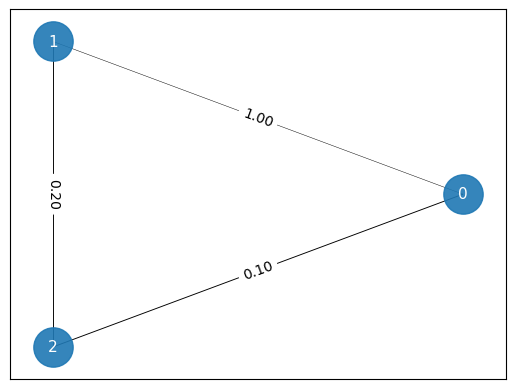

In [58]:
Draw_G_with_edge_weights(G)

## Compute modularity

We need the number of nodes, $N$. If this were an unweighted graph, then $m$ would be the number of edges, which is also half the sum of the entries in the adj matrix.

When the graph is weighted, then it is just $\frac{1}{2}\sum_{i=1}^N \sum_{j=1}^N a_{ij}$ where $a_{ij}$ are the entries of the adjaceny matrix.

In [4]:
A = nx.to_numpy_array(G, weight="weight")
print(A)

N = G.number_of_nodes() 
m = 0.5*np.sum(A) # m= number_of_edges()
print(f"N={N}, m={m}")

[[0.  1.  0.1]
 [1.  0.  0.2]
 [0.1 0.2 0. ]]
N=3, m=1.3


Weight sum

In [5]:
k = A.sum(axis=1)
print(k)

[1.1 1.2 0.3]


### Example 1

Compute modularity (no communities). $\delta$ is the identity matrix

In [6]:
delta = np.identity(N) 

In [7]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

nxM = nx.community.modularity(G,[{0},{1},{2}],weight="weights")
print(f"Modularity is M={M}.  nx.M={nxM}")

Modularity is M=-0.40532544378698226.  nx.M=-0.3333333333333333


### Example 2: 0 & 1 in community

In [8]:
delta = np.identity(N) 
delta[0,1]=1
delta[1,0]=1
print(delta)

[[1. 1. 0.]
 [1. 1. 0.]
 [0. 0. 1.]]


In [9]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M} = {nx.community.modularity(G,[{0,2},{1}],weight="weights" )}")

Modularity is -0.026627218934911243 = -0.2222222222222222


### Example 2: 0 & 2 in community

In [10]:
delta = np.identity(N) 
delta[np.ix_([0, 2], [0, 2])] = 1
print(delta)

[[1. 0. 1.]
 [0. 1. 0.]
 [1. 0. 1.]]


In [11]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M} = {nx.community.modularity(G,[{0,2},{1}],weight="weights" )}")

Modularity is -0.42603550295858 = -0.2222222222222222


### Example 1 and 2 in same community?

In [12]:
delta = np.identity(N) 
delta[np.ix_([1, 2], [1, 2])] = 1
print(delta)

[[1. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]]


In [13]:
M = 0
for i in range(N):
    for j in range(N):
        M += (A[i,j]-k[i]*k[j]/(2.0*m))*delta[i,j]
M /= (2.0*m)

print(f"Modularity is {M}")

Modularity is -0.3579881656804733


## Average degree matrix

Let's look at the average degree matrix. First we need a new example.

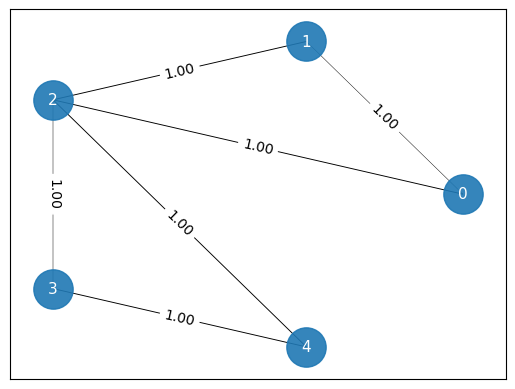

In [59]:
G2 = nx.Graph() # makes THE empty graph
G2.add_weighted_edges_from([(0, 1, 1), (0,2,1), (1,2,1), (2,3,1), (2,4,1), (3,4,1)])
Draw_G_with_edge_weights(G2)

In [60]:
A = nx.to_numpy_array(G2, weight="weight")
print(A)
N = G2.number_of_nodes() 
m = 0.5*np.sum(A) # m= number_of_edges()
print(f"N={N}, m={m}")

[[0. 1. 1. 0. 0.]
 [1. 0. 1. 0. 0.]
 [1. 1. 0. 1. 1.]
 [0. 0. 1. 0. 1.]
 [0. 0. 1. 1. 0.]]
N=5, m=6.0


In [61]:
k = A.sum(axis=1)
print(k)

[2. 2. 4. 2. 2.]


In [62]:
X = np.outer(k,k)/(2*m)
print(X)

[[0.33333333 0.33333333 0.66666667 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.66666667 0.33333333 0.33333333]
 [0.66666667 0.66666667 1.33333333 0.66666667 0.66666667]
 [0.33333333 0.33333333 0.66666667 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.66666667 0.33333333 0.33333333]]


Plot the associated Chung-Lu configuration mode

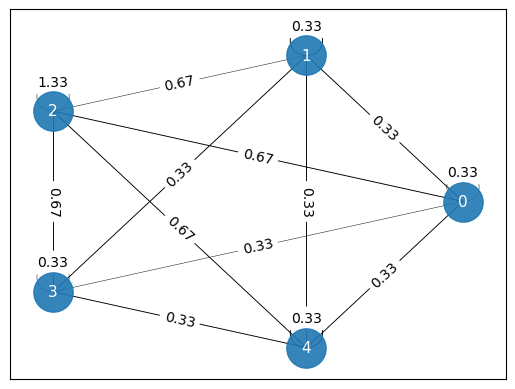

In [64]:
GX = nx.from_numpy_array(X)
Draw_G_with_edge_weights(GX)

{}


In [29]:
G = nx.dodecahedral_graph()
edge_labels = nx.draw_networkx_edge_labels(G)

TypeError: draw_networkx_edge_labels() missing 1 required positional argument: 'pos'